In [1]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


import numpy as np
import warnings
warnings.filterwarnings('ignore')



In [2]:
df = sns.load_dataset('penguins')
df.head(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
df.columns


Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [4]:
df.shape


(344, 7)

In [5]:
df.dtypes


species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

In [6]:
print("Missing")
print(df.isnull().sum())

Missing
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [7]:
 df.duplicated().sum()


np.int64(0)

In [8]:
df_clean = df.drop_duplicates()

In [9]:
median_bill_length_mm  = df_clean['bill_length_mm'].median()
df_clean['bill_length_mm'].fillna(median_bill_length_mm , inplace= True)

median_bill_depth_mm  = df_clean['bill_depth_mm'].median()

df_clean['bill_depth_mm'].fillna(median_bill_depth_mm , inplace= True)

median_flipper_length_mm  = df_clean['flipper_length_mm'].median()
df_clean['flipper_length_mm'].fillna(median_flipper_length_mm , inplace= True)

median_body_mass_g  = df_clean['body_mass_g'].median()
df_clean['body_mass_g'].fillna(median_body_mass_g , inplace= True)


In [10]:
mode_sex  = df_clean['sex'].mode()[0]
df_clean['sex'].fillna(mode_sex , inplace= True)


In [11]:
print("Missing")
print(df_clean.isnull().sum())

Missing
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


In [12]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     344 non-null    float64
 3   bill_depth_mm      344 non-null    float64
 4   flipper_length_mm  344 non-null    float64
 5   body_mass_g        344 non-null    float64
 6   sex                344 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [13]:
biscoe_df = df_clean[df_clean['island'] == 'Biscoe']
biscoe_df.shape

(168, 7)

In [14]:
median_body_mass_g  = df_clean['body_mass_g'].mean()
heavy_males = df_clean[(df_clean['body_mass_g'] > median_body_mass_g)&(df_clean['sex'] =="Male")]
heavy_males.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,Male
14,Adelie,Torgersen,34.6,21.1,198.0,4400.0,Male
17,Adelie,Torgersen,42.5,20.7,197.0,4500.0,Male
39,Adelie,Dream,39.8,19.1,184.0,4650.0,Male


In [15]:
sorted_datetime = df_clean.sort_values(by=['body_mass_g', 'bill_length_mm'], ascending=[False, True])

sorted_datetime.head(10) 

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
237,Gentoo,Biscoe,49.2,15.2,221.0,6300.0,Male
253,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,Male
337,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,Male
297,Gentoo,Biscoe,51.1,16.3,220.0,6000.0,Male
299,Gentoo,Biscoe,45.2,16.4,223.0,5950.0,Male
331,Gentoo,Biscoe,49.8,15.9,229.0,5950.0,Male
233,Gentoo,Biscoe,48.4,14.6,213.0,5850.0,Male
235,Gentoo,Biscoe,49.3,15.7,217.0,5850.0,Male
335,Gentoo,Biscoe,55.1,16.0,230.0,5850.0,Male
295,Gentoo,Biscoe,48.6,16.0,230.0,5800.0,Male


In [16]:
df_clean.groupby('species')['body_mass_g'].mean().sort_values(ascending=False)

species
Gentoo       5067.741935
Chinstrap    3733.088235
Adelie       3702.960526
Name: body_mass_g, dtype: float64

In [17]:
df_clean.groupby(['species','sex'])['bill_length_mm'].mean()

species    sex   
Adelie     Female    37.257534
           Male      40.280380
Chinstrap  Female    46.573529
           Male      51.094118
Gentoo     Female    45.563793
           Male      49.164394
Name: bill_length_mm, dtype: float64

In [18]:
df_clean.groupby('island').size()

island
Biscoe       168
Dream        124
Torgersen     52
dtype: int64

In [19]:
df_clean['bill_ratio'] = df_clean['bill_length_mm'] / df_clean['bill_depth_mm']

df_clean.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_ratio
0,Adelie,Torgersen,39.10,18.7,181.0,3750.0,Male,2.090909
1,Adelie,Torgersen,39.50,17.4,186.0,3800.0,Female,2.270115
2,Adelie,Torgersen,40.30,18.0,195.0,3250.0,Female,2.238889
3,Adelie,Torgersen,44.45,17.3,197.0,4050.0,Male,2.569364
4,Adelie,Torgersen,36.70,19.3,193.0,3450.0,Female,1.901554


In [20]:
df_clean['bill_ratio'].describe()

count    344.000000
mean       2.605438
std        0.495930
min        1.639810
25%        2.161882
50%        2.571484
75%        3.097572
max        3.612676
Name: bill_ratio, dtype: float64

In [21]:
df_clean.groupby('species')['bill_ratio'].mean().idxmax()

'Gentoo'

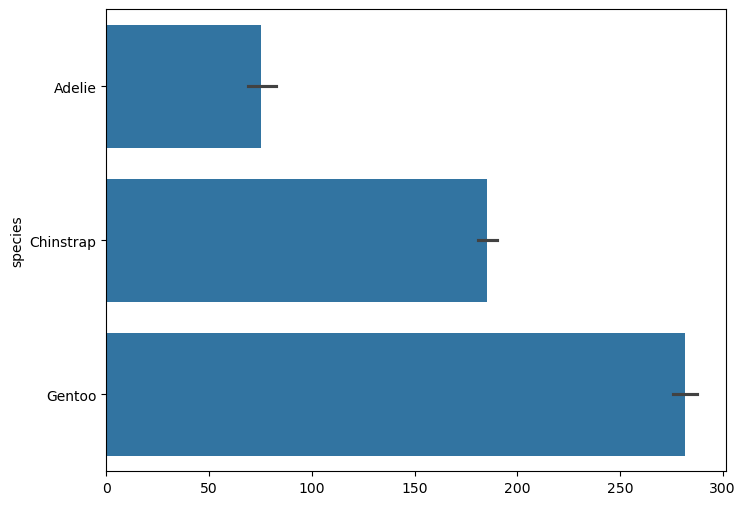

In [22]:
plt.figure(figsize=(8,6))
sns.barplot(data=df_clean['species'])

plt.show()


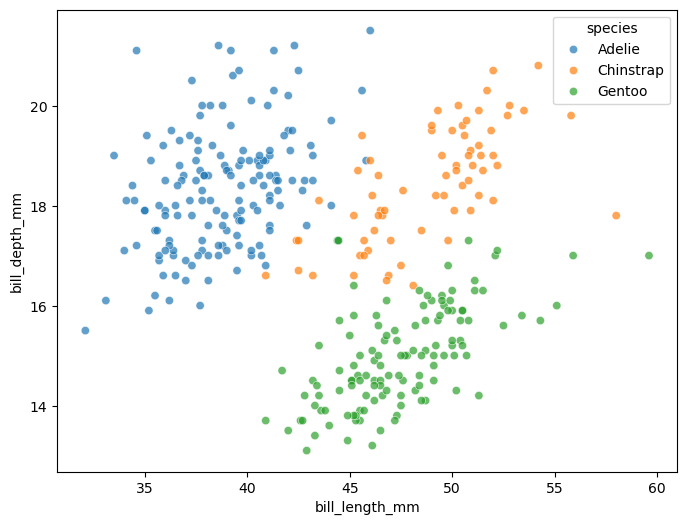

In [23]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_clean, x='bill_length_mm', y='bill_depth_mm', hue='species',  alpha=0.7)

plt.show()

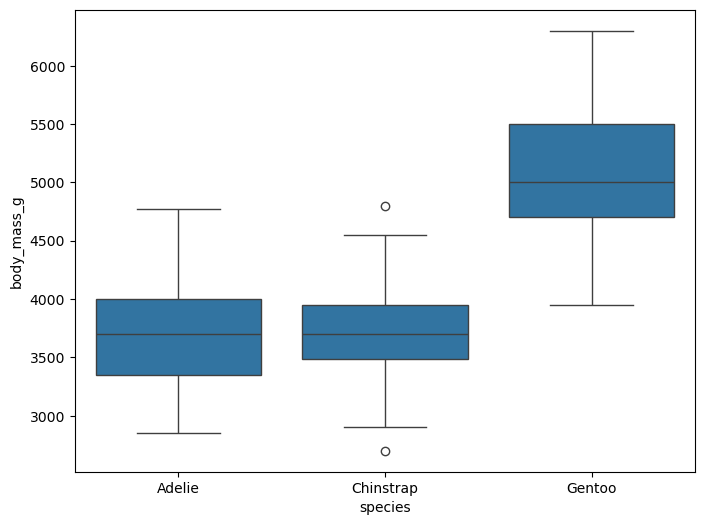

In [24]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_clean, y='body_mass_g', x='species' )

plt.show()

<h2>Interpretation</h2>

<p>
    
* Adelie and Chinstrap penguins have comparable and lower body masses compared to Gentoo penguins, with their medians falling closer to 3700g-3800g.
* The data suggests that Gentoo penguins are the heaviest of the three species shown in this dataset.</p>

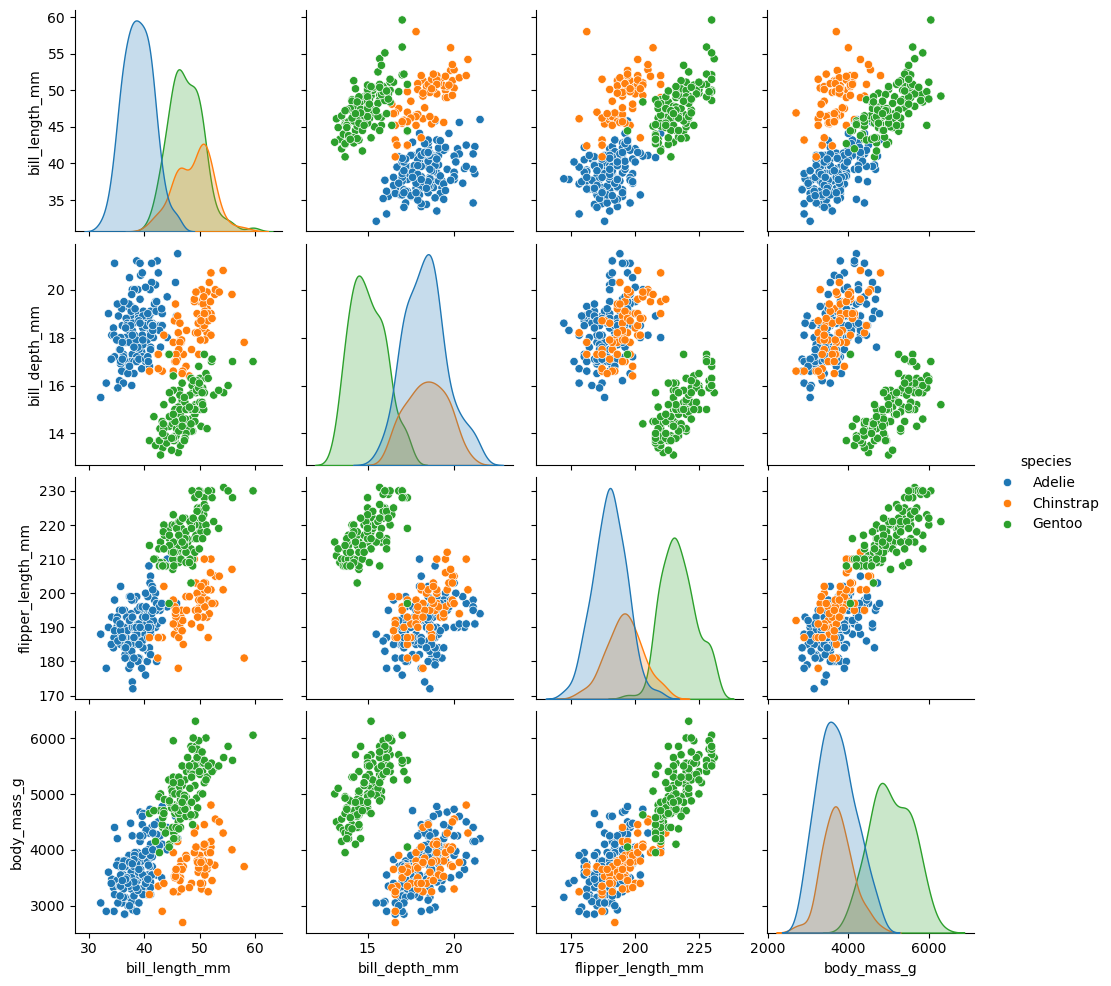

In [25]:
sns.pairplot(df_clean, vars=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'],
hue='species', diag_kind='kde')
plt.show()

In [26]:
y = df_clean['species']
X = df_clean.drop('species' , axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)
print(X_train.shape)


print(X_test.shape)

(275, 7)
(69, 7)


In [27]:
# Identify columns by type
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_transformer = Pipeline(steps=[
 ("imputer", SimpleImputer(strategy="median")),
 ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
 ("imputer", SimpleImputer(strategy="most_frequent")),
 ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocess = ColumnTransformer(
 transformers=[
 ("num", numeric_transformer, numeric_features),
 ("cat", categorical_transformer, categorical_features),
 ]
)

In [28]:
# 1) KNN pipeline
knn_model = Pipeline(steps=[
 ("preprocess", preprocess),
 ("model", KNeighborsClassifier(n_neighbors=5))
])


In [29]:
knn_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
y_pred = knn_model.predict(X_test)

In [31]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9855072463768116


In [32]:
logreg_model = Pipeline(steps=[
 ("preprocess", preprocess),
 ("model", LogisticRegression(max_iter=2000))
])

In [33]:


logreg_model.fit(X_train, y_train)



,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
y_pred = logreg_model.predict(X_test)


In [35]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

1.0


<h2>Q16: Conclude based on the accuracy results</h2>

<p>Logistic Regression achieved perfect accuracy (1.0) on the test set, while KNN achieved slightly lower accuracy (0.98). This is because the features in the dataset are almost linearly separable, which allows Logistic Regression to perfectly separate the classes, while KNN can make occasional mistakes due to nearby points influencing its predictions.</p>

In [ ]:
sns.heatmap(df_clean dtype = 'numerical')
